In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import scipy
from mp_api.client import MPRester
import torch
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN
import warnings
import GNN

In [4]:
with MPRester("5ckknLVXj2HhtTHt9pzCjWGJcOFTJmHm") as mpr:
    doc = mpr.materials.summary.search(
        num_chunks = 1,
        chunk_size = 1000,
        fields=["material_id", "structure", "band_gap", "formula_pretty", "symmetry"],
        is_metal = False 
    )


Retrieving SummaryDoc documents:   0%|          | 0/1000 [00:00<?, ?it/s]

In [6]:
cnn = CrystalNN()
warnings.filterwarnings("ignore")

def has_valid_neighbors(structure):
    for atom_idx in range(len(structure)):
        try:
            neighbors = cnn.get_nn_info(structure, atom_idx)
            if len(neighbors) == 0:
                return False
        except ValueError:
            return False
    return True

valid_doc = []
skipped = []

for itm in doc:
    if has_valid_neighbors(itm.structure):
        valid_doc.append(itm)
    else:
        skipped.append(itm.material_id)

doc = valid_doc  

In [7]:
targets = []
for i in doc:
    targets.append(i.band_gap)
targets = torch.tensor(targets, dtype = torch.float)


In [8]:
def get_valence_features(specie):
    try:
        L, num_electrons = specie.valence
        L_onehot = [1 if L == i else 0 for i in range(4)]
        return L_onehot + [num_electrons]
    except ValueError:
        return [0, 0, 0, 0] + [0]

In [9]:
def safe(val, default=0.0):
    return val if val is not None else default

In [10]:
def bond_ionicity(specie1, specie2):
    x1 = safe(specie1.X)
    x2 = safe(specie2.X)
    delta_en = abs(x1 - x2)
    return delta_en  # keep as a continuous feature, not a hard category

In [11]:
node_data = []

for i in doc:
    molecule_data = []
    struc = i.structure
    for site in struc:
        atom_feats = []
        atom_feats.append(safe(site.specie.Z))
        atom_feats.append(safe(site.specie.X))
        atom_feats.append(safe(site.specie.atomic_mass))
        atom_feats.append(safe(site.specie.atomic_radius))
        atom_feats.append(safe(site.specie.electron_affinity))
        atom_feats.append(safe(site.specie.group))
        atom_feats.append(safe(site.specie.row))
        atom_feats.append(safe(site.specie.ionization_energy))
        atom_feats += get_valence_features(site.specie)
        molecule_data.append(atom_feats)
    node_data.append(torch.tensor(molecule_data, dtype = torch.float))

node_data[0].shape


torch.Size([5, 13])

In [12]:
edge_data = []             
edge_index_list = [] 

for itm in doc:
    struc = itm.structure

    bond_index_src = []
    bond_index_tgt = []
    bond_features = []

    for atom_idx, site in enumerate(struc):
        neighbors = cnn.get_nn_info(struc, atom_idx)

        seen = set()
        for n in neighbors:
            neighbor_idx = n['site_index']
            pair = (atom_idx, neighbor_idx)
            if pair in seen:
                continue 
            seen.add(pair)

            neighbor_site = n['site']
            bond_length = site.distance(neighbor_site)
            delta_en = bond_ionicity(site.specie, neighbor_site.specie)

            bond_index_src.append(atom_idx)
            bond_index_tgt.append(neighbor_idx)
            bond_features.append([bond_length, delta_en])

    edge_index_list.append(torch.tensor([bond_index_src, bond_index_tgt], dtype=torch.long))
    edge_data.append(torch.tensor(bond_features, dtype=torch.float))

print(edge_data[0].shape)
edge_index_list[0].shape

torch.Size([12, 2])


torch.Size([2, 12])

In [13]:
crystal_systems = ["Triclinic", "Monoclinic", "Orthorhombic", "Tetragonal", "Trigonal", "Hexagonal", "Cubic"]

global_data = []
for itm in doc:
    cs = itm.symmetry.crystal_system
    onehot = [1 if cs == s else 0 for s in crystal_systems]
    global_data.append(onehot)

global_data = torch.tensor(global_data, dtype=torch.float)  

global_data[0].shape

torch.Size([7])

In [19]:

model = GNN.GNN(nodefeats=13, edgefeats=2, ndim=128, edim=64, globfeats=7, num_layers=5)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0003)
epochs = 20
losses = []
epoch_losses=[]
for epoch in range(epochs):
    perm = torch.randperm(len(node_data))
    epoch_loss = 0.0
    for i in perm:
        i = i.item()
        model.zero_grad()
        out = model.forward(node_data[i], edge_data[i], edge_index_list[i], global_data[i])
        #print(f"{doc[i].formula_pretty}: predicted {out.item():.3f} eV, actual {targets[i].item():.3f} eV")
        loss = (out - targets[i])**2
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_losses.append(epoch_loss / len(node_data))

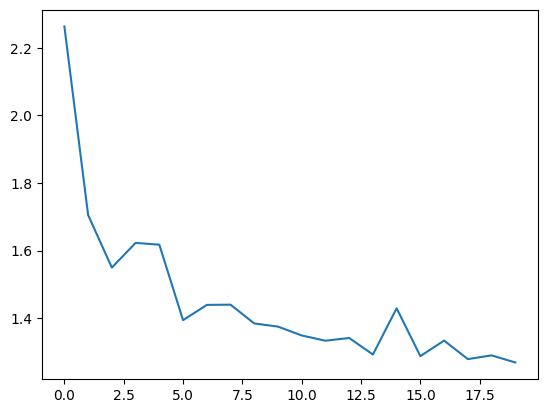

In [22]:
plt.plot(epoch_losses)

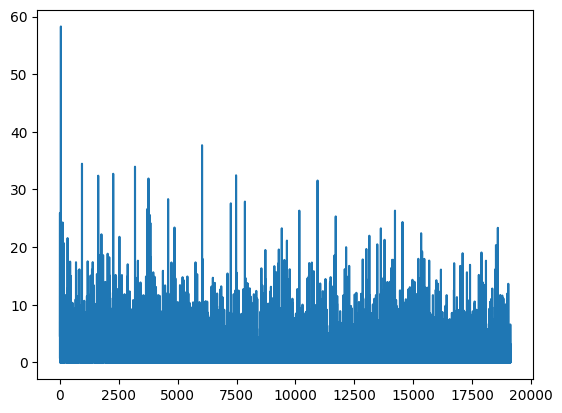

In [21]:
plt.plot(losses)